In [16]:
import matplotlib.pyplot as plt
import numpy as np
import common
from dataclasses import dataclass
from typing import List

In [17]:
%config InlineBackend.figure_format = 'retina'

In [18]:
@dataclass
class BarPlotData:
    y: List[float]
    name: str

@dataclass
class StackedBarPlotData:
    sub_bars: List[BarPlotData]
    categories: List[str]


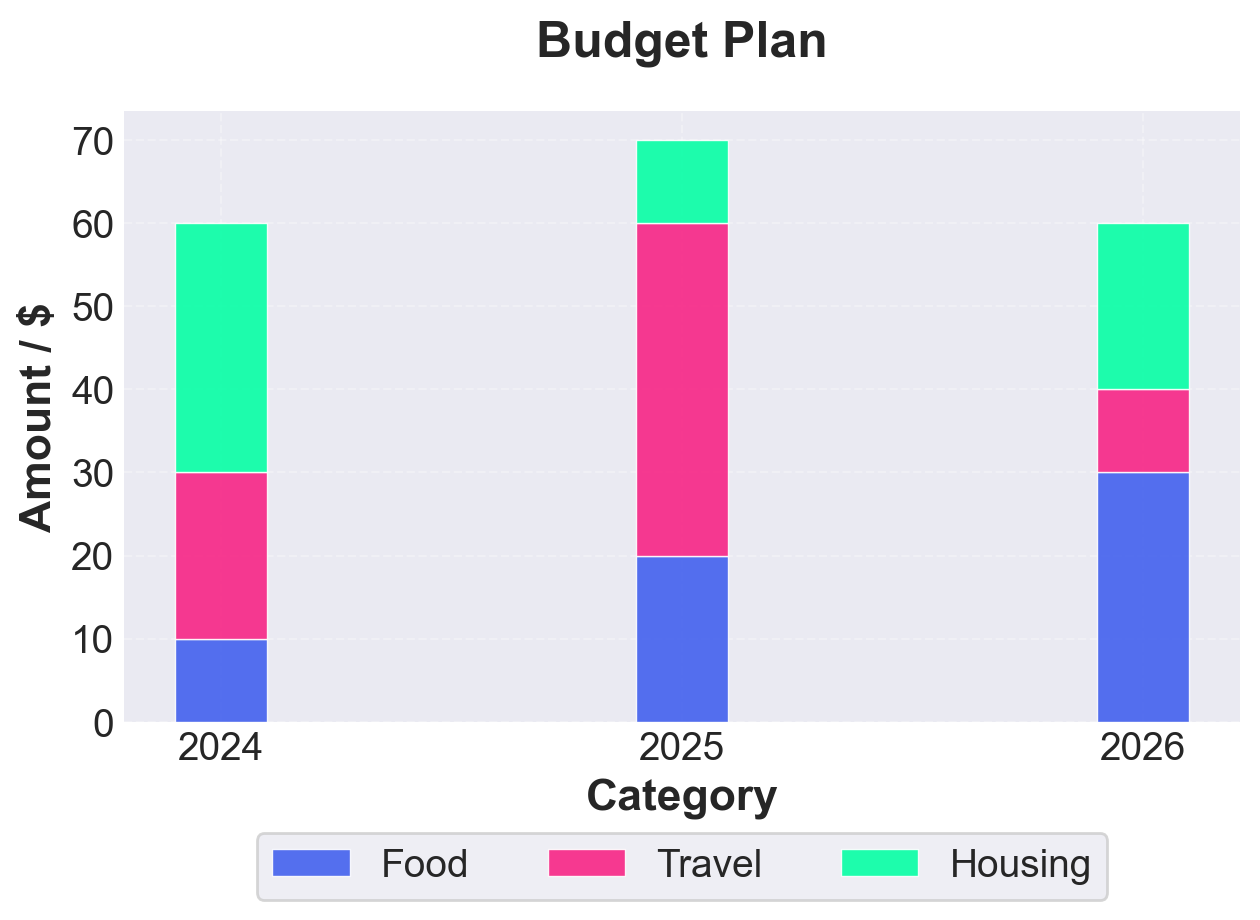

In [21]:
def generate_stacked_bar_plot(
        stacked_data: StackedBarPlotData, 
        x_label: str,
        y_label: str,
        title: str, 
        show_legend: bool = True, 
        show_grid: bool = True, 
        num_legend_cols: int = 2):
    # compute the x point of each bar
    num_bars = len(stacked_data.sub_bars)
    num_categories = len(stacked_data.categories)
    categories = stacked_data.categories
    bottom_val = np.zeros(num_categories)
    
    x = np.arange(num_categories)

    for idx, data in enumerate(stacked_data.sub_bars):
        data: BarPlotData
        
        # stack the bar on the bottom of the previous bar
        plt.bar(
            x=x, 
            height=data.y, 
            color=common.COLORS[idx], 
            edgecolor='white', 
            linewidth=0.5, 
            alpha=0.9, 
            width=0.2,
            label=data.name,
            bottom=bottom_val
        )

        bottom_val += data.y


    plt.xlabel(x_label, fontsize=common.LABEL_FONT_SIZE, fontweight='bold')
    plt.ylabel(y_label, fontsize=common.LABEL_FONT_SIZE, fontweight='bold')
    plt.title(title, fontsize=common.TITLE_SIZE, fontweight='bold', pad=20)
    plt.xticks(x, categories, fontsize=common.X_TICK_FONT_SIZE)
    plt.yticks(fontsize=common.Y_TICK_FONT_SIZE)

    if show_legend:
        # put legend below the plot
        plt.legend(frameon=True, fontsize=common.LEGEND_FONT_SIZE, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=num_legend_cols)

    if show_grid:
        plt.grid(True, alpha=0.3, linestyle='--')

    plt.tight_layout()


# Generate sample data
stacked_data = StackedBarPlotData(
            sub_bars=[
                BarPlotData(y=[10, 20, 30], name='Food'),
                BarPlotData(y=[20, 40, 10], name='Travel'),
                BarPlotData(y=[30, 10, 20], name='Housing'),
            ],
            categories=['2024', '2025', '2026']
        )


generate_stacked_bar_plot(
        stacked_data=stacked_data,
        x_label='Category',
        y_label='Amount / $',
        title='Budget Plan',
        show_legend=True,
        show_grid=True,
        num_legend_cols=3
)
plt.show()